# Hafta 1 — Kayan Nokta Aritmetiği, Hata Analizi ve Koşullanma

> **Sıfırdan Sayısal Yöntemler** · Saf NumPy + Matplotlib · SciPy yok, hazır kütüphane yok.

Tek bir denklem çözmeden önce rahatsız edici bir gerçekle yüzleşmemiz gerekiyor: **bilgisayar çoğu reel sayıyı temsil edemez.** Bu derslerdeki her algoritma, sayıları sonlu sayıda bitte saklayan sonlu bir makinede çalışır. Reel sayı doğrusu $\mathbb{R}$ ile makine sayılarının oluşturduğu sonlu küme $\mathbb{F}$ arasındaki bu boşluk, bilimsel hesaplamadaki neredeyse her ince hatanın kaynağıdır.

Bu hafta temeli atıyoruz:

1. IEEE-754 kayan nokta modeli ve **makine epsilonu**.
2. **Mutlak vs. bağıl hata** ve neden genellikle bağıl hatayı önemsediğimiz.
3. **Felaket düzeyinde sadeleşme (catastrophic cancellation)** — neredeyse eşit sayıları çıkarmanın hassasiyeti nasıl yok ettiği.
4. Bir problemin **koşullanması (conditioning)** ile bir algoritmanın **kararlılığı (stability)**.
5. **İleri / geri hata** ve bunları birbirine bağlayan *temel kural*.

Sonunda bir formüle bakıp *nerede* doğruluk kaybedeceğini öngörebileceksiniz — bu, herhangi tek bir yöntemden daha değerli bir beceridir.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=17)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Kayan nokta modeli

Normalize edilmiş bir IEEE-754 çift hassasiyetli (double) sayı şu şekilde saklanır:

$$ x = \pm (1 + f)\, 2^{e}, \qquad f = \sum_{i=1}^{52} b_i\, 2^{-i}, \quad b_i\in\{0,1\}, $$

burada $e$ 11-bitlik üs ve $f$ 52-bitlik kesirdir. Tüm bu sayıların kümesi $\mathbb{F}$ ile gösterilir.

Anahtar büyüklük **birim yuvarlama (unit roundoff)** ya da makine epsilonu $u$'dur. Çift hassasiyet için:

$$ u = 2^{-53} \approx 1.11\times 10^{-16}. $$

Kayan nokta aritmetiğinin temel aksiyomu, aralık içindeki herhangi bir reel $x$'in yuvarlanmış sonucu $\mathrm{fl}(x)$ için şunu söyler:

$$ \mathrm{fl}(x) = x(1+\delta), \qquad |\delta| \le u. $$

Yani: **saklanan her sayı en fazla $u$ kadar bağıl hata taşır.** $u$'yu deneysel olarak bulalım.


In [2]:
# NumPy'nin bildirdiği "epsilon", 1.0 ile bir sonraki float arasındaki boşluktur,
# yani 2*u = 2^-52. Literatürde iki tanım da geçer.
eps_aralik = np.finfo(np.float64).eps          # 2^-52, 1.0 üzerindeki boşluk
birim_yuvarlama = eps_aralik / 2                # 2^-53, yuvarlama sınırı u

print("makine epsilonu (boşluk 2^-52):", eps_aralik)
print("birim yuvarlama  u   (2^-53)  :", birim_yuvarlama)

# Deneysel kontrol: 1 + e == 1 olana kadar yarıya bölerek boşluğu bul
e = 1.0
while 1.0 + e != 1.0:
    e /= 2.0
print("1+e==1 yapan en küçük e (yarılayarak):", e, "-> boşluk ~", 2*e)


makine epsilonu (boşluk 2^-52): 2.220446049250313e-16
birim yuvarlama  u   (2^-53)  : 1.1102230246251565e-16
1+e==1 yapan en küçük e (yarılayarak): 1.1102230246251565e-16 -> boşluk ~ 2.220446049250313e-16


### Sayı doğrusu düzgün aralıklı değildir

Kayan nokta sayıları **logaritmik aralıklıdır**: ardışık sayılar arasındaki boşluk büyüklükle birlikte artar. $x$ civarındaki boşluk yaklaşık $u\cdot|x|$ kadardır — bu da tam olarak *bağıl* hatanın neden doğal ölçü birimi olduğunu açıklar.


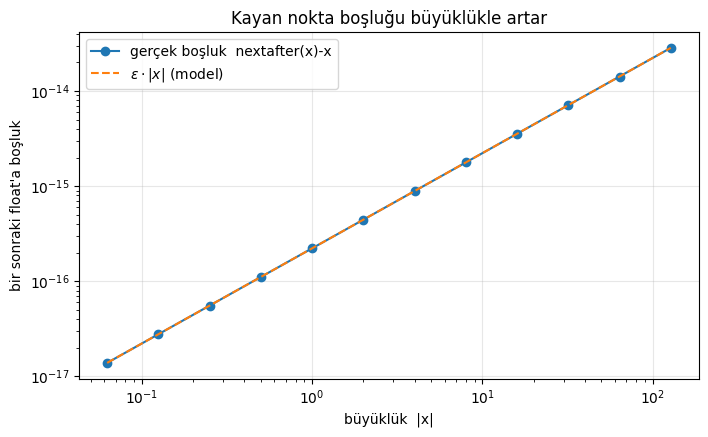

In [3]:
buyukluk = 2.0 ** np.arange(-4, 8)
bosluk = np.array([np.nextafter(m, np.inf) - m for m in buyukluk])

fig, ax = plt.subplots()
ax.loglog(buyukluk, bosluk, "o-", label="gerçek boşluk  nextafter(x)-x")
ax.loglog(buyukluk, eps_aralik * buyukluk, "--", label=r"$\epsilon \cdot |x|$ (model)")
ax.set_xlabel("büyüklük  |x|")
ax.set_ylabel("bir sonraki float'a boşluk")
ax.set_title("Kayan nokta boşluğu büyüklükle artar")
ax.legend()
plt.show()


## 2. Mutlak vs. bağıl hata

$\hat{x}$, gerçek değer $x$'i yaklaşık olarak göstersin. O zaman:

$$ \text{mutlak hata} = |x - \hat{x}|, \qquad \text{bağıl hata} = \frac{|x-\hat{x}|}{|x|}\;(x\neq 0). $$

Bağıl hata doğrudan **anlamlı basamak** sayısına bağlanır: $\approx 10^{-k}$ bağıl hata, kabaca $k$ doğru anlamlı ondalık basamak demektir. Çift hassasiyet bunların yaklaşık 15–16 tanesini verir.


In [4]:
def hatalar(gercek, yaklasik):
    mutlak = abs(gercek - yaklasik)
    bagil = mutlak / abs(gercek) if gercek != 0 else np.inf
    anlamli_basamak = -np.log10(bagil) if bagil > 0 else np.inf
    return mutlak, bagil, anlamli_basamak

for gercek, yaklasik in [(np.pi, 3.14159), (1e8, 1e8 + 3), (1e-8, 1.01e-8)]:
    m, b, s = hatalar(gercek, yaklasik)
    print(f"gerçek={gercek:<12g} yaklaşık={yaklasik:<14g} mutlak={m:.3e}  bağıl={b:.3e}  ~{s:.1f} basamak")


gerçek=3.14159      yaklaşık=3.14159        mutlak=2.654e-06  bağıl=8.447e-07  ~6.1 basamak
gerçek=1e+08        yaklaşık=1e+08          mutlak=3.000e+00  bağıl=3.000e-08  ~7.5 basamak
gerçek=1e-08        yaklaşık=1.01e-08       mutlak=1.000e-10  bağıl=1.000e-02  ~2.0 basamak


Ortadaki satır öğreticidir: $3$'lük mutlak hata büyük görünür ama $10^8$'e göre bağıl hatası minik — yaklaşık 8 doğru basamak. Bağlam her şeydir.

## 3. Felaket düzeyinde sadeleşme

İçselleştirilmesi gereken en önemli başarısızlık türü budur. Neredeyse eşit iki sayıyı çıkardığımızda, baştaki basamaklar sadeleşir ve **bağıl hata patlar**, çünkü hayatta kalan küçük basamaklar zaten yuvarlamayla kirlenmiştir.

Klasik örnek ikinci derece denklem formülüdür:

$$ x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}. $$

$b^2 \gg 4ac$ olduğunda, $-b + \sqrt{b^2-4ac}$ kullanan kök neredeyse eşit iki büyüklüğü çıkarır. Hatayı görelim, sonra düzeltelim.


In [5]:
def kokler_saf(a, b, c):
    d = np.sqrt(b*b - 4*a*c)
    return ((-b + d) / (2*a), (-b - d) / (2*a))

def kokler_kararli(a, b, c):
    # Sadeleşmeyi önle: "güvenli" kökü hesapla, sonra x1*x2 = c/a çarpımını kullan.
    d = np.sqrt(b*b - 4*a*c)
    if b >= 0:
        x_buyuk = (-b - d) / (2*a)
    else:
        x_buyuk = (-b + d) / (2*a)
    x_kucuk = c / (a * x_buyuk)        # Vieta formülü, eşitlerin çıkarılması yok
    return (x_buyuk, x_kucuk)

a, b, c = 1.0, 1e8, 1.0          # küçük kök -1e-8 civarında
print("saf    :", kokler_saf(a, b, c))
print("kararlı:", kokler_kararli(a, b, c))

# Küçük kök a*x^2+b*x+c = 0 sağlamalı. Kalıntıyı (residual) kontrol et.
xk_saf = kokler_saf(a, b, c)[0]
xk_kararli = kokler_kararli(a, b, c)[1]
print("kalıntı saf     küçük kök:", a*xk_saf**2 + b*xk_saf + c)
print("kalıntı kararlı küçük kök:", a*xk_kararli**2 + b*xk_kararli + c)


saf    : (np.float64(-7.450580596923828e-09), np.float64(-100000000.0))
kararlı: (np.float64(-100000000.0), np.float64(-1e-08))
kalıntı saf     küçük kök: 0.2549419403076172
kalıntı kararlı küçük kök: 1.1102230246251565e-16


Saf küçük kök, kararlı olandan kat kat daha büyük bir kalıntı taşır. **Aynı matematik, kökten farklı doğruluk** — kararlı ve kararsız bir algoritma arasındaki fark budur.

### İkinci sadeleşme örneği: küçük $x$ için $1 - \cos x$

Çok küçük $x$ için $\cos x \approx 1$, dolayısıyla $1 - \cos x$ neredeyse eşit sayıları çıkarır. $1-\cos x = 2\sin^2(x/2)$ özdeşliği bu çıkarmayı tamamen ortadan kaldırır.


In [6]:
xs = np.logspace(-9, -1, 9)
saf = 1 - np.cos(xs)
kararli = 2 * np.sin(xs/2)**2

print(f"{'x':>10} {'saf':>14} {'kararlı':>14} {'bağıl hata (saf)':>18}")
for x, n, s in zip(xs, saf, kararli):
    ref = x**2/2*(1 - x**2/12)        # Taylor referansı, küçük x için doğru
    bagil = abs(n - ref)/abs(ref)
    print(f"{x:10.1e} {n:14.6e} {s:14.6e} {bagil:18.2e}")


         x            saf        kararlı   bağıl hata (saf)
   1.0e-09   0.000000e+00   5.000000e-19           1.00e+00
   1.0e-08   0.000000e+00   5.000000e-17           1.00e+00
   1.0e-07   4.996004e-15   5.000000e-15           7.99e-04
   1.0e-06   5.000445e-13   5.000000e-13           8.89e-05
   1.0e-05   5.000000e-11   5.000000e-11           8.27e-08
   1.0e-04   5.000000e-09   5.000000e-09           5.24e-09
   1.0e-03   5.000000e-07   5.000000e-07           1.57e-11
   1.0e-02   4.999958e-05   4.999958e-05           2.81e-11
   1.0e-01   4.995835e-03   4.995835e-03           2.78e-07


$x = 10^{-9}$ için saf formülde esasen **sıfır doğru basamak** kalır, yeniden yazılmış biçim ise doğru kalır. Ders: *cebirsel olarak eşdeğer ifadeler sayısal olarak eşdeğer değildir.*

## 4. Koşullanma vs. kararlılık

Bu iki kavram sıkça karıştırılır. Kesinlikle ayrı tutun:

- **Koşullanma**, *problemin* bir özelliğidir. Girdi değiştirildiğinde çıktının ne kadar değiştiğini ölçer; algoritmadan bağımsızdır.
- **Kararlılık**, *algoritmanın* bir özelliğidir. Kararlı bir algoritma, yuvarlama hatalarını koşullanmanın zaten dayattığından fazla büyütmez.

Türevlenebilir bir $f$ fonksiyonunu $x$'te değerlendirmek için (bağıl) **koşul sayısı**:

$$ \kappa_f(x) = \left| \frac{x\, f'(x)}{f(x)} \right|. $$

Yanıtladığı soru: *girdideki %1'lik değişim çıktıda kabaca %$\kappa$ değişime yol açar.* $\kappa \gg 1$ olduğunda problem **kötü koşulludur** ve hiçbir algoritma — ne kadar zekice olursa olsun — hatalı girdiden doğru bir yanıt veremez.


In [7]:
def kosul_sayisi(f, df, x):
    return abs(x * df(x) / f(x))

# f(x) = ln(x): x=1 yakınında değer ->0 olurken türev sonlu kalır, kappa patlar.
f  = np.log
df = lambda x: 1.0 / x
xs = np.array([0.5, 0.9, 0.99, 0.999, 1.0001])
for x in xs:
    print(f"x={x:<8} kappa(log)={kosul_sayisi(f, df, x):12.4f}")


x=0.5      kappa(log)=      1.4427
x=0.9      kappa(log)=      9.4912
x=0.99     kappa(log)=     99.4992
x=0.999    kappa(log)=    999.4999
x=1.0001   kappa(log)=  10000.5000


In [8]:
# Deneysel doğrulama: girdiyi bilinen bir bağıl miktarla bozup çıktıyı izle.
x0 = 0.999
delta = 1e-6                          # girdinin bağıl bozulması
x_bozuk = x0 * (1 + delta)
bagil_cikti = abs(np.log(x_bozuk) - np.log(x0)) / abs(np.log(x0))
print("öngörülen büyütme (kappa):", kosul_sayisi(f, df, x0))
print("gözlenen   büyütme       :", bagil_cikti / delta)


öngörülen büyütme (kappa): 999.4999166249727
gözlenen   büyütme       : 999.4994168213996


Gözlenen büyütme koşul sayısıyla örtüşür — teori soyut değil, göreceğiniz basamak kaybını *öngörür*.

## 5. İleri ve geri hata

$\hat{y} \approx f(x)$ hesaplayan bir algoritma verildiğinde:

- **İleri hata (forward error)**: $|\hat{y} - f(x)|$ — yanıt ne kadar yanlış?
- **Geri hata (backward error)**: $\hat{y} = f(x + \Delta x)$ eşitliğini *tam olarak* sağlayan en küçük $\Delta x$ — yanıtımız hangi yakın girdi için doğru olurdu?

İkisi sayısal analizin temel kuralıyla bağlanır:

$$ \boxed{\;\text{ileri hata} \;\lesssim\; \text{koşul sayısı} \times \text{geri hata}\;} $$

*Geriye doğru kararlı (backward-stable)* bir algoritma küçük bir geri hata üretir ($u$ mertebesinde). Yanıt yine de hatalıysa suç algoritmada değil, problemin koşullanmasındadır.


In [9]:
# Kararlı ikinci derece çözücüyle örnek: bir kök hassas olsa bile geri hata minik.
a, b, c = 1.0, 1e6, 2.0
x_buyuk, x_kucuk = kokler_kararli(a, b, c)

# Geri hata: kökleri TAM olarak (x_buyuk, x_kucuk) olan polinomu Vieta ile yeniden kur:
# toplam = -b/a, çarpım = c/a.
b_geri = -(x_buyuk + x_kucuk) * a
c_geri = (x_buyuk * x_kucuk) * a
print("girdi      b, c :", b, c)
print("ima edilen b, c :", b_geri, c_geri)
print("geri hata  b    :", abs(b - b_geri)/abs(b))
print("geri hata  c    :", abs(c - c_geri)/abs(c))


girdi      b, c : 1000000.0 2.0
ima edilen b, c : 1000000.0 2.0
geri hata  b    : 0.0
geri hata  c    : 0.0


İma edilen katsayılar girdilerle esasen aynı: algoritma, sorduğumuza *sonsuz küçük yakın* bir problemi çözdü. İşte bu, geriye doğru kararlılıktır.

## Özet

- Makine sayıları en fazla $u \approx 1.1\times 10^{-16}$ birim yuvarlamayla sınırlı bağıl hata taşır; boşluk büyüklükle artar.
- **Bağıl hata** anlamlı basamak sayısını ölçer; tek başına **mutlak hata** yanıltıcıdır.
- **Felaket düzeyinde sadeleşme** neredeyse eşit sayıları çıkarırken hassasiyeti yok eder — formülleri bundan kaçınacak şekilde yeniden yazın.
- **Koşullanma** probleme, **kararlılık** algoritmaya aittir; birini diğeri için suçlamayın.
- ileri hata $\lesssim$ koşul sayısı $\times$ geri hata, bu derslerdeki her yöntemi değerlendireceğimiz mercektir.

---

## Alıştırmalar

**1. (İki yoldan varyans.)** "Ders kitabı" tek-geçişli varyans formülü $\frac{1}{n}\sum x_i^2 - \bar{x}^2$ sadeleşmeden muzdariptir. `x = 1e9 + np.random.randn(10000)` üretip varyansı (a) tek-geçişli ve (b) iki-geçişli $\frac{1}{n}\sum (x_i-\bar{x})^2$ formülüyle hesaplayın. İkisini `np.var(x)` ile karşılaştırıp farkı sadeleşme açısından açıklayın.

**2. (Çıkarmanın koşul sayısı.)** $f(x,y)=x-y$ fonksiyonunun girdi çifti açısından koşul sayısının $\frac{|x|+|y|}{|x-y|}$ olduğunu analitik olarak gösterin. Hangi girdilerde patlar? Bunu 1. alıştırmaya bağlayın.

**3. (Yalan söyleyen seri.)** Üstel fonksiyon $e^{-x}$ doğrudan $\sum_k \frac{(-x)^k}{k!}$ olarak toplanabilir. $x=20$ için kodlayıp `np.exp(-20)` ile karşılaştırın. Neden felaket düzeyinde yanlış ve $1/\big(\sum_k \frac{x^k}{k!}\big)$ hesaplamak bunu neden düzeltir?

**4. (Kendi geri hatanız.)** Bir kübik $p(x)=x^3+ax^2+bx+c$ için yaklaşık bir kök $\hat{r}$ verildiğinde geri hatayı kestiren bir fonksiyon yazın: $\hat{r}$'yi tam kök yapan en küçük katsayı bozulması. Bilerek bozduğunuz bir kökte test edin.

**5. (Boşluk deneyi.)** `x = 10.0 ** np.arange(0, 16)` boyunca `np.nextafter(x, inf) - x` boşluğunu ölçüp $u\cdot|x|$ ile takip ettiğini doğrulayın. Hangi büyüklükte boşluk 1.0'ı aşar (yani ardışık tam sayılar temsil edilemez olur)?
